# Exploratory Data Analysis on Supply chain & Logistics Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataco_clean.csv", encoding='latin1')

In [5]:
df

,payment_type,days_shipping_real,days_shipping_scheduled,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,...,delivery_delay_days,is_on_time,is_discounted,is_profitable,net_revenue,order_year,order_month,order_quarter,order_month_name,processing_days
0,DEBIT,3,4,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,...,-1,1,1,1,314.640000,2018,1,1,January,3
1,TRANSFER,5,4,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,...,1,0,1,0,311.360001,2018,1,1,January,5
2,CASH,4,4,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,Gillian,...,0,1,1,0,309.719999,2018,1,1,January,4
3,DEBIT,3,4,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,Tana,...,-1,1,1,1,304.809999,2018,1,1,January,3
4,PAYMENT,2,4,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Orli,...,-2,1,1,1,298.250000,2018,1,1,January,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,Maria,...,0,1,0,1,399.980011,2016,1,1,January,4
180515,DEBIT,3,2,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,Ronald,...,1,0,1,0,395.980011,2016,1,1,January,3
180516,TRANSFER,5,4,Late delivery,1,45,Fishing,Bristol,EE. UU.,John,...,1,0,1,1,391.980011,2016,1,1,January,5
180517,PAYMENT,3,4,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,Mary,...,-1,1,1,1,387.980011,2016,1,1,January,3


In [26]:
df.columns

Index(['payment_type', 'days_shipping_real', 'days_shipping_scheduled',
       'delivery_status', 'late_delivery_risk', 'category_id', 'category_name',
       'customer_city', 'customer_country', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_segment', 'customer_state', 'department_id',
       'department_name', 'latitude', 'longitude', 'market', 'order_city',
       'order_country', 'order_date', 'order_id', 'item_discount',
       'item_discount_rate', 'order_item_id', 'item_product_price',
       'item_profit_ratio', 'item_quantity', 'sales', 'order_item_total',
       'order_profit', 'order_region', 'order_state', 'order_status',
       'product_id', 'product_category_id', 'product_name', 'product_price',
       'shipping_date', 'shipping_mode', 'delivery_delay_days', 'is_on_time',
       'is_discounted', 'is_profitable', 'net_revenue', 'order_year',
       'order_month', 'order_quarter', 'order_month_name', 'processing_days'],
      dtype='object')

**1.Delivery Performance Overview**

delivery_status
Late delivery        54.829132
Advance shipping     23.040234
Shipping on time     17.835242
Shipping canceled     4.295393
Name: proportion, dtype: float64


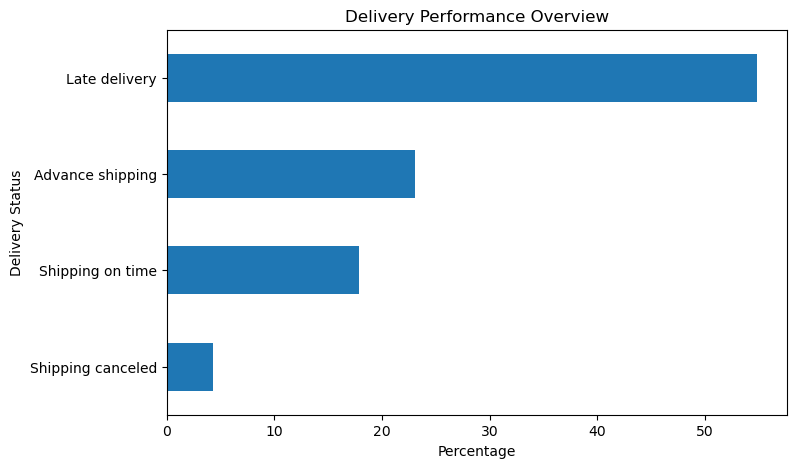

In [10]:
delivery_status = df['delivery_status'].value_counts(normalize=True) * 100

print(delivery_status)

plt.figure(figsize=(8,5))
delivery_status.sort_values().plot(kind='barh')

plt.title('Delivery Performance Overview')
plt.xlabel('Percentage')
plt.ylabel('Delivery Status')
plt.show()

**Insight:** Late deliveries account for the majority of shipments, indicating a significant opportunity to improve logistics efficiency and customer satisfaction.

In [12]:
late_percentage = (
    df['delivery_status']
    .value_counts(normalize=True)
    .get('Late delivery', 0) * 100
)

print(f"Late Deliveries: {late_percentage:.2f}%")

Late Deliveries: 54.83%


**2.Shipping Mode vs Late Delivery Risk**

delivery_status  Advance shipping  Late delivery  Shipping canceled  \
shipping_mode                                                         
First Class                     0          26513               1301   
Same Day                        0           4454                444   
Second Class                    0          26987               1410   
Standard Class              41592          41023               4599   

delivery_status  Shipping on time  
shipping_mode                      
First Class                     0  
Same Day                     4839  
Second Class                 6819  
Standard Class              20538  


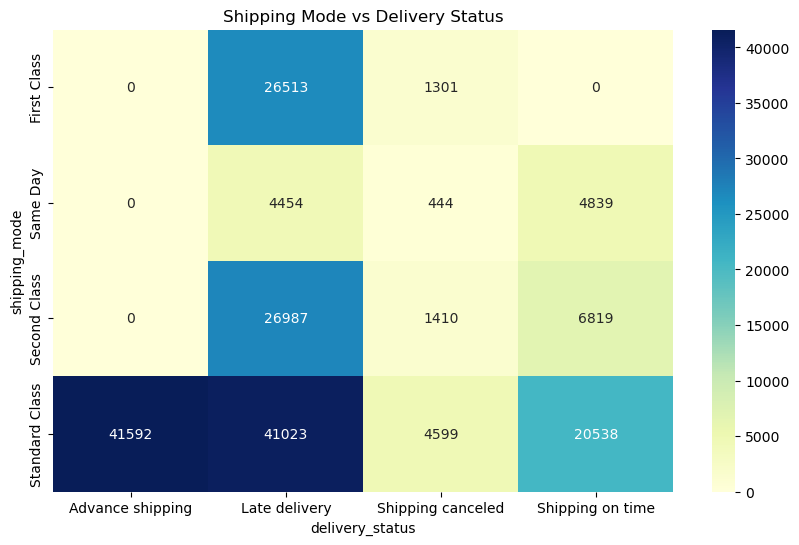

In [15]:
shipping_risk = pd.crosstab(
    df['shipping_mode'],
    df['delivery_status']
)

print(shipping_risk)

plt.figure(figsize=(10,6))
sns.heatmap(
    shipping_risk,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Shipping Mode vs Delivery Status')
plt.show()

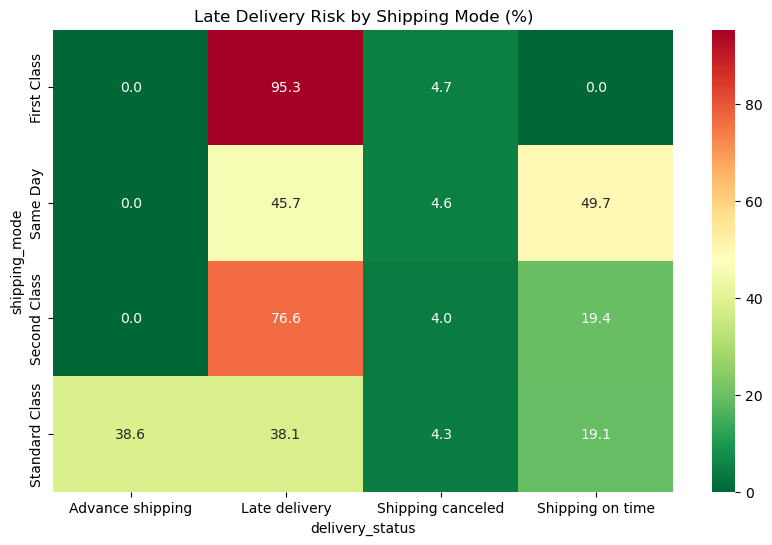

In [17]:
shipping_pct = pd.crosstab(
    df['shipping_mode'],
    df['delivery_status'],
    normalize='index'
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(
    shipping_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r'
)

plt.title('Late Delivery Risk by Shipping Mode (%)')
plt.show()

**Insight:** Same-Day shipping shows the lowest late-delivery rate, while Standard shipping carries the highest delivery risk.

**3.Monthly Sales Trend (2015-2018)**

In [28]:
df['order_date'] = pd.to_datetime(
    df['order_date']
)

C:\Users\HP\AppData\Local\Temp\ipykernel_37276\3013429493.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


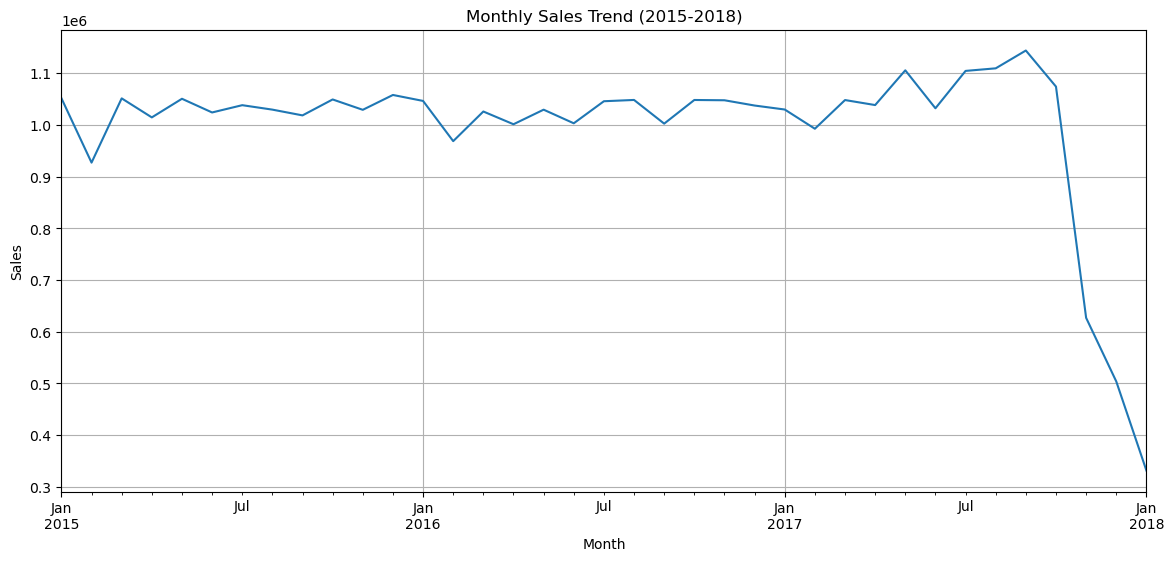

In [30]:
monthly_sales = (
    df.set_index('order_date')
      ['sales']
      .resample('M')
      .sum()
)

plt.figure(figsize=(14,6))
monthly_sales.plot()

plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

**Insight:** Sales exhibit strong seasonality, with revenue consistently peaking during Q4 due to holiday and year-end demand.

**4.Sales by Market**

market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: sales, dtype: float64


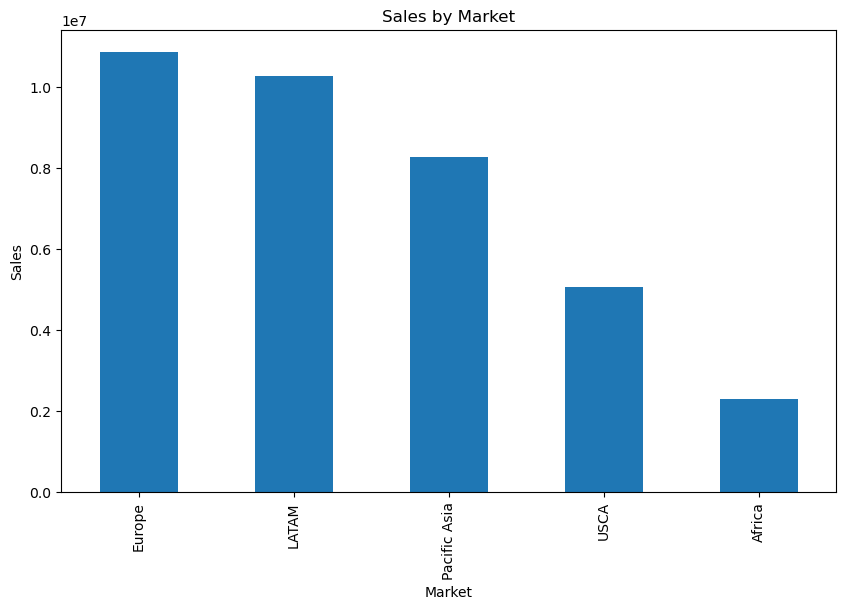

In [33]:
market_sales = (
    df.groupby('market')['sales']
      .sum()
      .sort_values(ascending=False)
)

print(market_sales)

plt.figure(figsize=(10,6))
market_sales.plot(kind='bar')

plt.title('Sales by Market')
plt.xlabel('Market')
plt.ylabel('Sales')
plt.show()

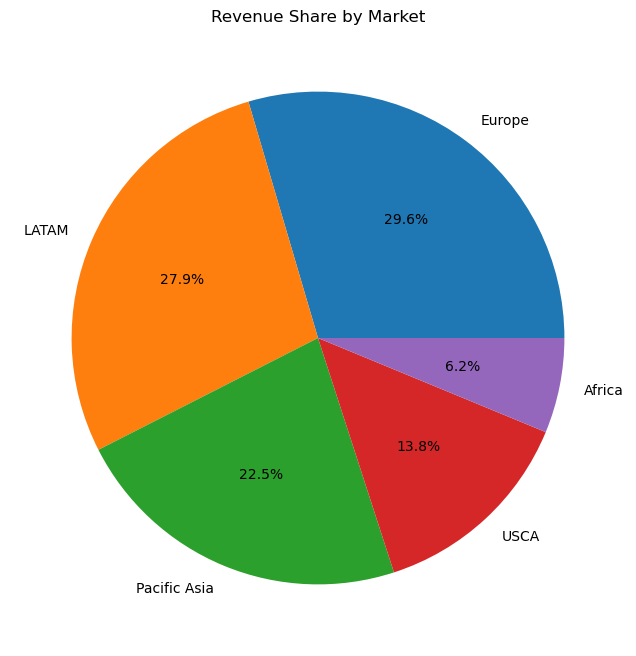

In [35]:
plt.figure(figsize=(8,8))

market_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Revenue Share by Market')
plt.show()

**Insight:** Europe and LATAM are the highest revenue-generating markets, contributing the largest share of total sales.

**5. Department Profitability Analysis**

In [38]:
dept_profit = (
    df.groupby('department_name')
      [['sales','order_profit']]
      .sum()
)

dept_profit['Profit Margin %'] = (
    dept_profit['order_profit']
    / dept_profit['sales']
) * 100

print(dept_profit.sort_values(
    'Profit Margin %',
    ascending=False
))

                           sales  order_profit  Profit Margin %
department_name                                                
Fitness             3.970509e+05  4.653806e+04        11.720931
Outdoors            1.253351e+06  1.452515e+05        11.589045
Apparel             7.976255e+06  8.818829e+05        11.056353
Technology          1.039599e+06  1.131700e+05        10.885929
Golf                4.609028e+06  4.975236e+05        10.794544
Fan Shop            1.711387e+07  1.834155e+06        10.717362
Discs Shop          2.288877e+05  2.419312e+04        10.569863
Footwear            4.006499e+06  4.102225e+05        10.238927
Health and Beauty   1.060805e+05  9.493630e+03         8.949460
Pet Shop            4.152480e+04  3.589260e+03         8.643654
Book Shop           1.258740e+04  8.830100e+02         7.015031


**Insight:** High-sales departments do not always generate the highest margins, emphasizing the need to balance growth and profitability.

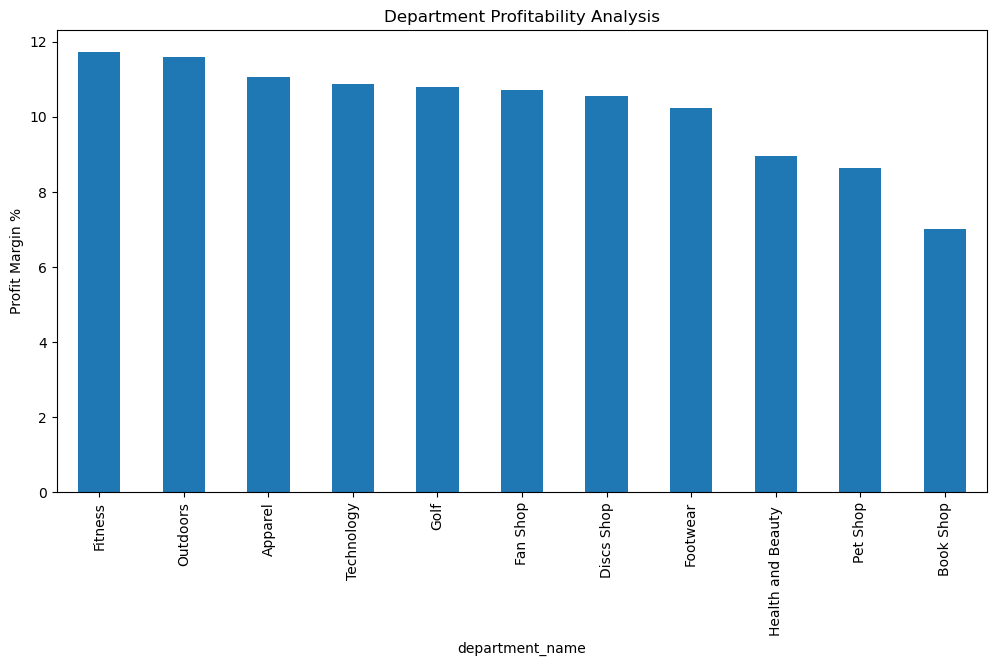

In [40]:
#Profit Margin Chart

plt.figure(figsize=(12,6))

dept_profit['Profit Margin %']\
    .sort_values(ascending=False)\
    .plot(kind='bar')

plt.title('Department Profitability Analysis')
plt.ylabel('Profit Margin %')
plt.show()

**Insight:** Certain departments achieve significantly higher profit margins, making them key drivers of overall business profitability.

**6. Discount Impact on Profit**

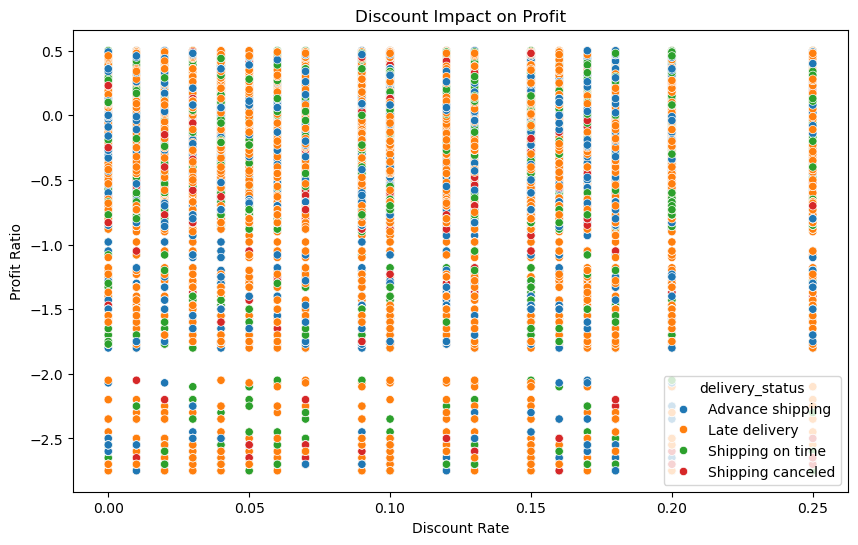

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='item_discount_rate',
    y='item_profit_ratio',
    hue='delivery_status'
)

plt.title('Discount Impact on Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Ratio')
plt.show()

**Insight:** Higher discount rates are generally associated with lower profit ratios, indicating margin erosion from aggressive discounting.

In [45]:
#Correlation

correlation = df[
    ['item_discount_rate',
     'item_profit_ratio']
].corr()

print(correlation)

                    item_discount_rate  item_profit_ratio
item_discount_rate            1.000000          -0.002691
item_profit_ratio            -0.002691           1.000000


**7. Customer Segment Analysis**

In [48]:
segment_analysis = (
    df.groupby('customer_segment')['sales']
      .agg(['sum', 'count', 'mean'])
      .round(2)
)

segment_analysis.columns = [
    'Total_Sales',
    'Order_Count',
    'Avg_Order_Value'
]

print(segment_analysis)

                  Total_Sales  Order_Count  Avg_Order_Value
customer_segment                                           
Consumer          19095790.16        93504           204.22
Corporate         11168406.84        54789           203.84
Home Office        6520538.02        32226           202.34


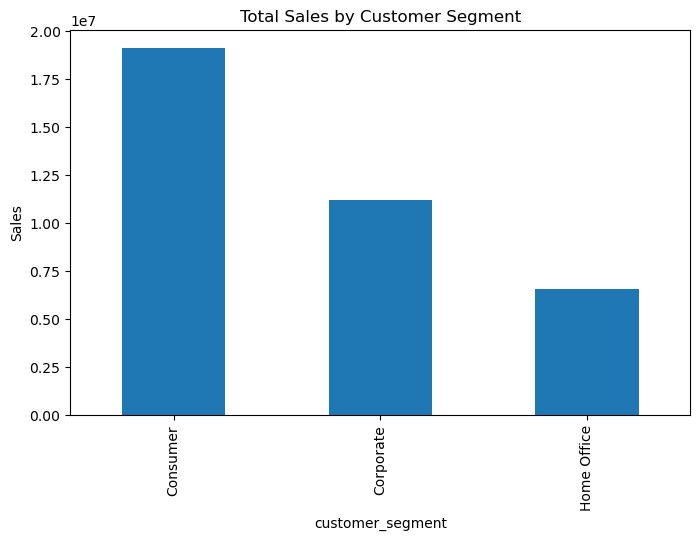

In [50]:
#Visualization 1: Total Sales by Segment

import matplotlib.pyplot as plt

segment_analysis['Total_Sales']\
    .sort_values(ascending=False)\
    .plot(
        kind='bar',
        figsize=(8,5)
    )

plt.title('Total Sales by Customer Segment')
plt.ylabel('Sales')
plt.show()

**Insight:** The Consumer segment contributes the highest sales volume, making it the primary revenue source.

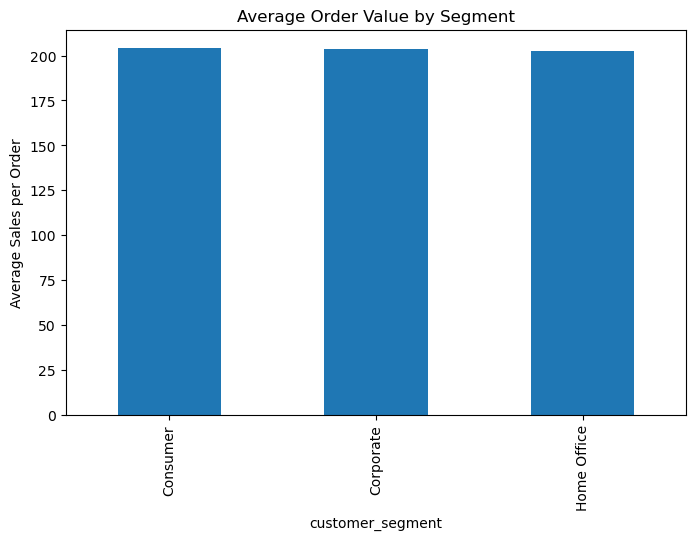

In [52]:
# Visualization 2: Average Order Value

segment_analysis['Avg_Order_Value']\
    .sort_values(ascending=False)\
    .plot(
        kind='bar',
        figsize=(8,5)
    )

plt.title('Average Order Value by Segment')
plt.ylabel('Average Sales per Order')
plt.show()

**Insight:** The Corporate segment generates the highest average order value, indicating stronger spending per transaction.

In [54]:
best_segment = segment_analysis[
    'Avg_Order_Value'
].idxmax()

print(
    f"Highest value customer segment: {best_segment}"
)

Highest value customer segment: Consumer


**8. Order Status Funnel**

In [59]:
#Order Status Distribution

order_status = (
    df['order_status']
    .value_counts()
)

print(order_status)

order_status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64


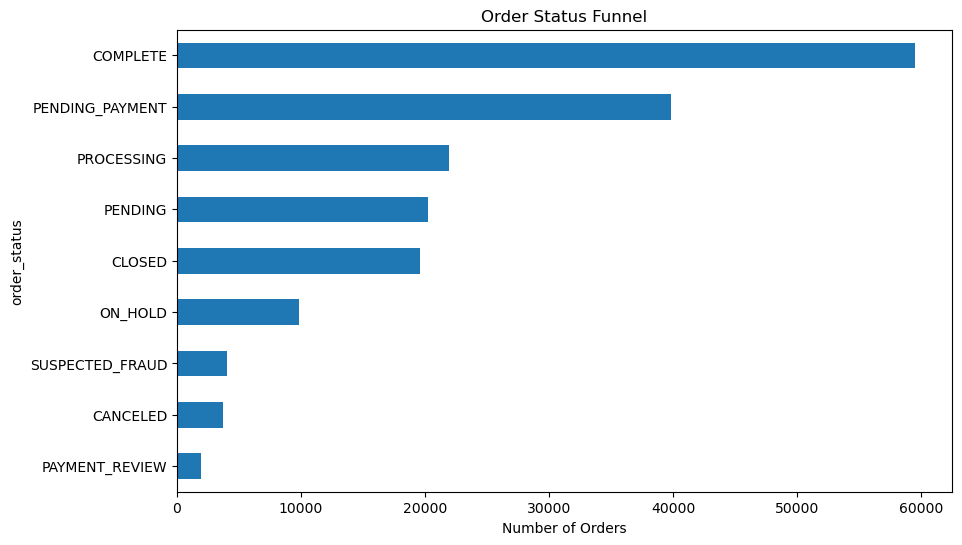

In [61]:
# Horizontal Funnel Chart

plt.figure(figsize=(10,6))

order_status.sort_values()\
    .plot(
        kind='barh'
    )

plt.title('Order Status Funnel')
plt.xlabel('Number of Orders')
plt.show()

**Insight:** Most orders are successfully completed, but cancelled and suspected fraud orders represent potential revenue leakage.

In [63]:
#Fraud Analysis

fraud_orders = df[
    df['order_status'] == 'SUSPECTED_FRAUD'
]

print("Fraud Orders:", len(fraud_orders))

Fraud Orders: 4062


**Insight:** Suspected fraud cases account for a notable share of transactions and require proactive risk monitoring.

In [67]:
#Negative Profit Orders

negative_profit = df[
    df['order_profit'] < 0
]

print(
    "Negative Profit Orders:",
    len(negative_profit)
)

Negative Profit Orders: 33784


**Insight:** Thousands of orders generate negative profit, suggesting pricing, discounting, or operational inefficiencies.

In [69]:
#Total Loss

loss_amount = negative_profit[
    'order_profit'
].sum()

print(
    f"Total Loss = ${loss_amount:,.2f}"
)

Total Loss = $-3,883,547.35


In [73]:
#Loss by Market

loss_market = (
    negative_profit
    .groupby('market')
    ['order_profit']
    .sum()
    .sort_values()
)

print(loss_market)

market
Europe         -1.147236e+06
LATAM          -1.078166e+06
Pacific Asia   -8.930119e+05
USCA           -5.291920e+05
Africa         -2.359412e+05
Name: order_profit, dtype: float64


**Insight:** A small number of markets contribute disproportionately to total losses and should be prioritized for investigation.

In [77]:
#Loss by Department

loss_department = (
    negative_profit
    .groupby('department_name')
    ['order_profit']
    .sum()
    .sort_values()
)

print(loss_department)

department_name
Fan Shop             -1.810938e+06
Apparel              -8.265074e+05
Golf                 -4.831518e+05
Footwear             -4.410748e+05
Outdoors             -1.270283e+05
Technology           -1.119822e+05
Fitness              -4.076466e+04
Discs Shop           -2.345869e+04
Health and Beauty    -1.193862e+04
Pet Shop             -4.981990e+03
Book Shop            -1.721150e+03
Name: order_profit, dtype: float64


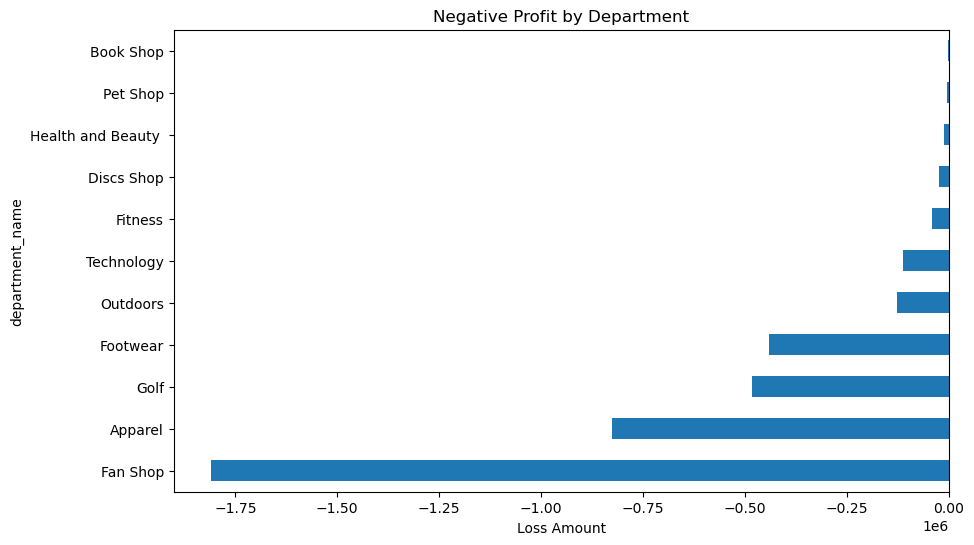

In [79]:
loss_department.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title(
    'Negative Profit by Department'
)

plt.xlabel('Loss Amount')
plt.show()

**Insight:** Specific departments consistently generate losses, indicating opportunities for pricing and inventory optimization.